In [3]:
!git clone https://github.com/aliakseizvertouski/olist.git

Cloning into 'olist'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 46 (delta 20), reused 3 (delta 2), pack-reused 14 (from 1)
Receiving objects: 100% (46/46), 42.55 MiB | 19.23 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
customers = pd.read_csv('/content/olist/olist_customers_dataset.csv')
geo = pd.read_csv('/content/olist/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/content/olist/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/content/olist/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/content/olist/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist/olist_products_dataset.csv')
sellers = pd.read_csv('/content/olist/olist_sellers_dataset.csv')

# Соблюдение сроков доставки

In [6]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

delivered_orders['estimated_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])
delivered_orders['actual_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])

delivered_orders['is_late'] = delivered_orders['actual_date'] > delivered_orders['estimated_date']

delivery_stats = delivered_orders['is_late'].value_counts()
delivery_stats.index = ['вовремя', 'опоздание']

total_orders = len(delivered_orders)
late_percent = (delivery_stats['опоздание'] / total_orders) * 100

print(f"Всего доставлено заказов: {total_orders}")
print(delivery_stats)
print(f"Процент опозданий: {late_percent:.2f}%\n")

Всего доставлено заказов: 96478
вовремя      88652
опоздание     7826
Name: count, dtype: int64
Процент опозданий: 8.11%



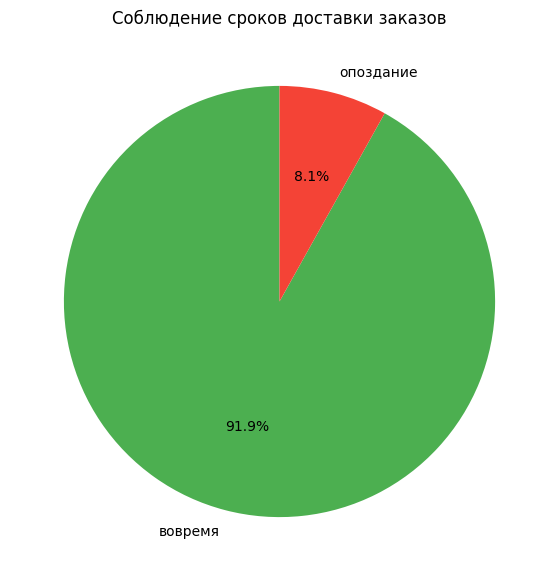

In [7]:
plt.figure(figsize=(7, 7))

plt.pie(
    delivery_stats,
    labels=delivery_stats.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90
)

plt.title('Соблюдение сроков доставки заказов')
plt.show()

## Самый долгий этап заказа

In [8]:
df = orders[orders['order_status'] == 'delivered'].copy()

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df['days_to_approve'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 86400
df['days_to_carrier'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / 86400
df['days_to_customer'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / 86400

mean_times = {
    '1. Подтверждение': df['days_to_approve'].mean(),
    '2. Сборка и склад': df['days_to_carrier'].mean(),
    '3. Доставка курьером': df['days_to_customer'].mean()
}

results = pd.Series(mean_times)

print("Среднее время этапов (в днях):")
print(results.round(2))

Среднее время этапов (в днях):
1. Подтверждение        0.43
2. Сборка и склад       2.80
3. Доставка курьером    9.33
dtype: float64


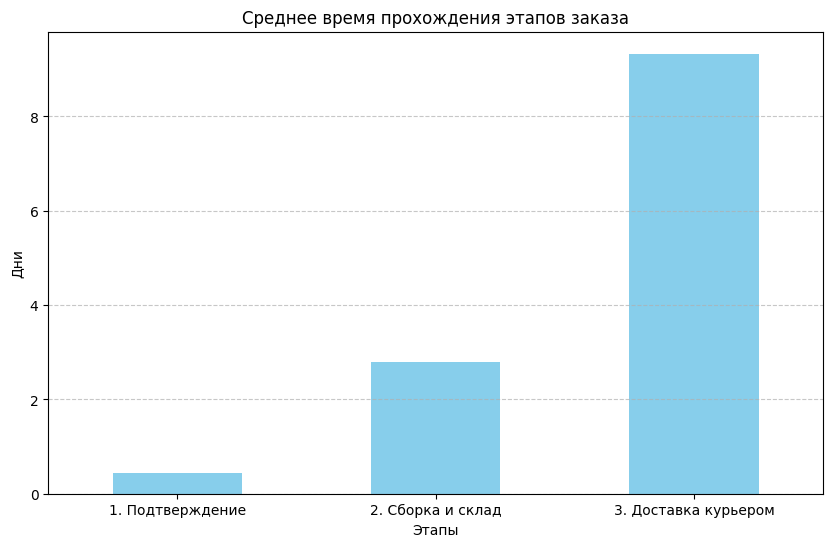

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
results.plot(kind='bar', color='skyblue')

plt.title('Среднее время прохождения этапов заказа')
plt.ylabel('Дни')
plt.xlabel('Этапы')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [10]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

df_geo = delivered_orders.merge(customers, on='customer_id')

df_geo['purchase'] = pd.to_datetime(df_geo['order_purchase_timestamp'])
df_geo['actual_delivery'] = pd.to_datetime(df_geo['order_delivered_customer_date'])
df_geo['estimated_delivery'] = pd.to_datetime(df_geo['order_estimated_delivery_date'])

df_geo['actual_days'] = (df_geo['actual_delivery'] - df_geo['purchase']).dt.total_seconds() / 86400
df_geo['estimated_days'] = (df_geo['estimated_delivery'] - df_geo['purchase']).dt.total_seconds() / 86400

state_stats = df_geo.groupby('customer_state')[['actual_days', 'estimated_days']].mean()

top_10_slowest = state_stats.sort_values(by='actual_days', ascending=False).head(10)

print("В какие штатты дольше всего доставляется товар?")
print(top_10_slowest.round(1))


В какие штатты дольше всего доставляется товар?
                actual_days  estimated_days
customer_state                             
RR                     29.4            46.0
AP                     27.2            46.2
AM                     26.4            45.3
AL                     24.5            32.6
PA                     23.8            37.2
MA                     21.6            30.5
SE                     21.5            30.8
CE                     21.3            31.4
AC                     21.0            41.1
PB                     20.4            33.0


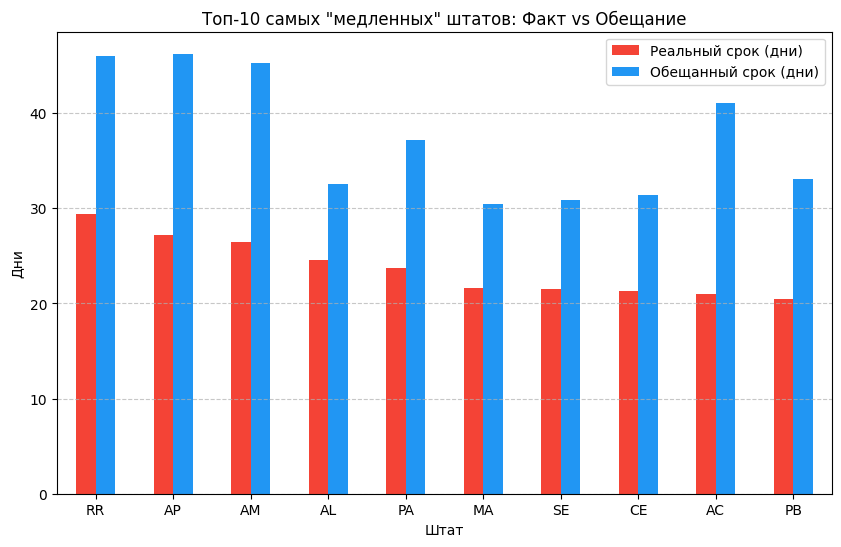

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
top_10_slowest.plot(kind='bar', ax=ax, color=['#f44336', '#2196f3'])

plt.title('Топ-10 самых "медленных" штатов: Факт vs Обещание')
plt.xlabel('Штат')
plt.ylabel('Дни')
plt.legend(['Реальный срок (дни)', 'Обещанный срок (дни)'])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

как будто обещанные сроки доставки завышены. но можно ли их снизить?

## Как часто опаздывают заказы? есть ли зависимость от региональности?

In [31]:
bad_states

,mean,count,delay_percent
customer_state,,,
AL,9.246130,95,1.213902
BA,11.099223,457,5.839509
CE,14.326787,196,2.504472
DF,6.638818,147,1.878354
ES,10.596163,244,3.117812
GO,9.788223,160,2.044467
MA,9.970709,141,1.801687
MG,7.528054,637,8.139535
MS,7.668138,81,1.035012


In [27]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
df_geo = delivered_orders.merge(customers, on='customer_id')

df_geo['actual_delivery'] = pd.to_datetime(df_geo['order_delivered_customer_date'])
df_geo['estimated_delivery'] = pd.to_datetime(df_geo['order_estimated_delivery_date'])

late_orders = df_geo[df_geo['actual_delivery'] > df_geo['estimated_delivery']].copy()

late_orders['delay_days'] = (late_orders['actual_delivery'] - late_orders['estimated_delivery']).dt.total_seconds() / 86400

bad_states = late_orders.groupby('customer_state')['delay_days'].agg(['mean', 'count'])

bad_states = bad_states[bad_states['count'] > 50]

#добавление % от общего количества задержанных заказов
bad_states['delay_percent'] = (bad_states['count'] / len(late_orders) * 100)

top_10_delays = bad_states.sort_values(by='mean', ascending=False).head(10)



print("Топ-10 штатов по среднему времени опоздания:")
print(top_10_delays.round(1))

Топ-10 штатов по среднему времени опоздания:
                mean  count  delay_percent
customer_state                            
SE              16.9     51            0.7
CE              14.3    196            2.5
RN              13.1     51            0.7
RJ              12.8   1664           21.3
PA              12.3    117            1.5
PI              12.3     76            1.0
PE              11.3    172            2.2
BA              11.1    457            5.8
ES              10.6    244            3.1
PB              10.5     57            0.7


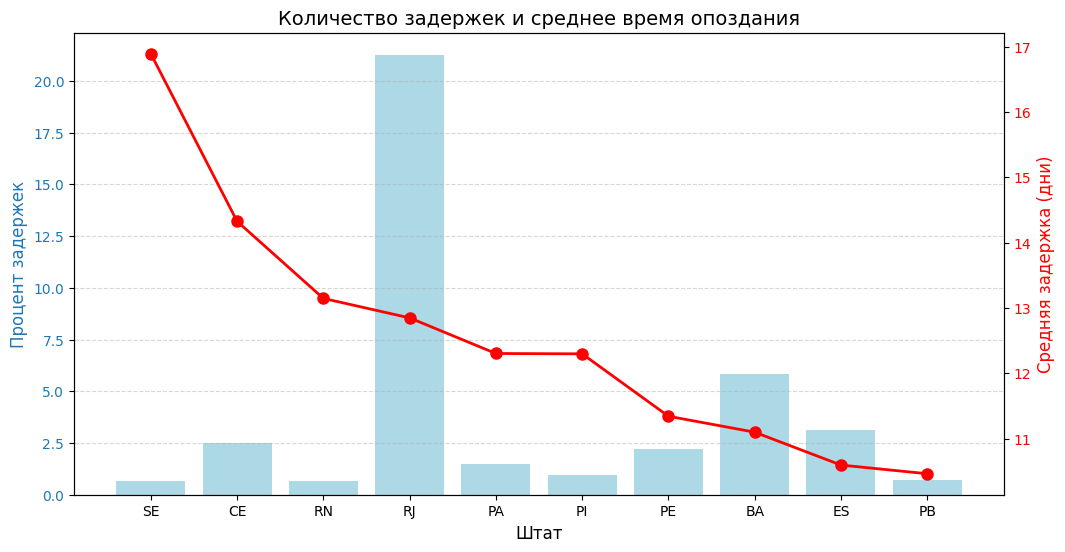

In [28]:
fig, ax1 = plt.subplots(figsize=(12, 6))

#count меняем на delay_percent
ax1.bar(top_10_delays.index, top_10_delays['delay_percent'], color='lightblue')
ax1.set_xlabel('Штат', fontsize=12)
#теперь это не "количество задержек(шт)", а "процент задержек"
ax1.set_ylabel('Процент задержек', color='tab:blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()

ax2.plot(top_10_delays.index, top_10_delays['mean'], color='red', marker='o', linewidth=2, markersize=8)
ax2.set_ylabel('Средняя задержка (дни)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Количество задержек и среднее время опоздания', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Отзывы покупателей

In [ ]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
reviews_df = delivered_orders.merge(order_reviews, on='order_id')

reviews_df['actual_date'] = pd.to_datetime(reviews_df['order_delivered_customer_date'])
reviews_df['estimated_date'] = pd.to_datetime(reviews_df['order_estimated_delivery_date'])

reviews_df['delivery_status'] = (reviews_df['actual_date'] > reviews_df['estimated_date']).map({True: 'С опозданием', False: 'Вовремя'})

mean_scores = reviews_df.groupby('delivery_status')['review_score'].mean()
print("Средняя оценка заказа:")
print(mean_scores.round(2))
print("--------------------------------------------")

score_distribution = pd.crosstab(reviews_df['delivery_status'], reviews_df['review_score'], normalize='index') * 100

print("Распределение оценок (в % от группы):")
print(score_distribution.round(1))

In [ ]:
ax = score_distribution.T.plot(kind='bar', figsize=(10, 6), color=['#4CAF50', '#F44336'])

plt.title('Влияние опоздания на оценку клиента', fontsize=14)
plt.xlabel('Оценка (от 1 до 5 звезд)', fontsize=12)
plt.ylabel('Доля заказов (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Статус доставки')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

тут хорошо видна зависимсть: главная причина негатевных отзывов - опоздание доставки

In [ ]:
reviews_full = order_reviews.merge(orders, on='order_id').merge(customers, on='customer_id')

state_reviews = reviews_full.groupby('customer_state')['review_id'].count().sort_values(ascending=False)

print("топ штатов по количеству отзывов:")
print(state_reviews.head(10))

In [ ]:
full_df = order_reviews.merge(orders, on='order_id').merge(customers, on='customer_id')

full_df['is_negative'] = full_df['review_score'] <= 2

state_sentiment = full_df.groupby('customer_state')['is_negative'].agg(['count', 'sum'])
state_sentiment.columns = ['total_reviews', 'negative_reviews']

state_sentiment['negative_ratio'] = (state_sentiment['negative_reviews'] / state_sentiment['total_reviews']) * 100

# state_sentiment = state_sentiment[state_sentiment['total_reviews'] > 100]

top_neg_count = state_sentiment.sort_values(by='negative_reviews', ascending=False).head(10)

print("Топ-10 штатов по к-ву негативных отзывов:")
top_neg_count

Выбиваются из статистики штаты SP (Сан Пауло) и MG (Миинас-Жерайс). Почему?

In [ ]:
full_df = order_reviews.merge(orders, on='order_id').merge(customers, on='customer_id')

target_states = ['SP', 'MG']
bad_reviews = full_df[
    (full_df['customer_state'].isin(target_states)) &
    (full_df['review_score'] <= 2)
].copy()

bad_reviews['actual_delivery'] = pd.to_datetime(bad_reviews['order_delivered_customer_date'])
bad_reviews['estimated_delivery'] = pd.to_datetime(bad_reviews['order_estimated_delivery_date'])
bad_reviews['is_late'] = bad_reviews['actual_delivery'] > bad_reviews['estimated_delivery']

late_fact_percent = (bad_reviews['is_late'].sum() / len(bad_reviews)) * 100

print(f"Всего негативных отзывов: {len(bad_reviews)} шт):")
print(f"Из них статус 'доставлены с опозданием': {late_fact_percent:.1f}%")

## Текстовый анализ отзывов

In [ ]:
bad_reviews['comment'] = bad_reviews['review_comment_message'].fillna('').str.lower()

bad_reviews['reason_delivery'] = bad_reviews['comment'].str.contains('atraso|demora|não recebi|nunca|nao chegou')

bad_reviews['reason_product'] = bad_reviews['comment'].str.contains('defeito|quebrado|errado|pessimo|ruim')

delivery_issues = bad_reviews['reason_delivery'].sum()
product_issues = bad_reviews['reason_product'].sum()
empty_comments = (bad_reviews['comment'] == '').sum()

print("На что жалуются в текстах отзывов:")
print(f"- Жалобы на доставку: {delivery_issues} упоминаний")
print(f"- Брак или ошибочный товар: {product_issues} упоминаний")
print(f"- Оставили оценку без текста: {empty_comments} шт")

In [ ]:
categories = ['Проблемы с доставкой', 'Брак / Не тот товар', 'Без текста']
counts = [delivery_issues, product_issues, empty_comments]

colors = ['#ff9999', '#66b3ff', '#d9d9d9']

plt.figure(figsize=(8, 8))

plt.pie(
    counts,
    labels=categories,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
)

plt.title('Причины негативных отзывов (SP и MG)', fontsize=15)
plt.show()